In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog

from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import optuna
from sklearn.model_selection import cross_val_score

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import warnings 
warnings.filterwarnings('ignore')

In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame = False)
X, y = mnist.data, mnist.target
y = y.astype(int)

In [3]:
print(f'Shape of X - {X.shape}\nShape of y - {y.shape}')

Shape of X - (70000, 784)
Shape of y - (70000,)


In [4]:
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

In [5]:
def extract_hog_features(X, image_size = (28,28)):
    hog_features = []
    for row in X:
        img = row.reshape(image_size)
        features = hog(
            img,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            feature_vector=True
        )
        hog_features.append(features)
    return np.array(hog_features)

In [6]:
X_train_hog = extract_hog_features(X_train)
X_test_hog = extract_hog_features(X_test)

In [7]:
baseline_model = LogisticRegression(random_state=42 , max_iter=200)

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

print(f'Baseline accuracy (raw pixels): {accuracy_score(y_test, y_pred_baseline):.4f}')

Baseline accuracy (raw pixels): 0.9229


In [8]:
n_subset = 8000
X_train_sub = X_train_hog[:n_subset]
y_train_sub = y_train[:n_subset]

In [9]:
svc = SVC(kernel='rbf', C=5, gamma='scale')
svc.fit(X_train_sub, y_train_sub)
y_pred_svc = svc.predict(X_test_hog)
print(f"SVM + HOG accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")

SVM + HOG accuracy: 0.9815


In [10]:
# def objective(trial):
#     C = trial.suggest_float('C', 0.1, 50, log=True)
#     gamma = trial.suggest_float('gamma', 1e-4, 1e-1, log=True)
    
#     model = SVC(kernel='rbf', C=C, gamma=gamma)
#     score = cross_val_score(model, X_train_sub, y_train_sub, cv=3, n_jobs=-1).mean()
#     return score

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=20) 

# print("Best params:", study.best_params)
# print("Best CV accuracy:", study.best_value)

In [11]:
import joblib

best_params = {'C': 11.73, 'gamma': 0.060} 

svc_final = SVC(kernel='rbf', **best_params)
svc_final.fit(X_train_hog, y_train)

y_pred_final = svc_final.predict(X_test_hog)
final_acc = accuracy_score(y_test, y_pred_final)
print(f"Final model accuracy: {final_acc:.4f}")

Final model accuracy: 0.9899


In [12]:
joblib.dump(svc_final, '../models/svm_digit_model.pkl')

hog_params = {
    'orientations': 9,
    'pixels_per_cell': (4, 4),
    'cells_per_block': (2, 2),
    'block_norm': 'L2-Hys'
}
joblib.dump(hog_params, '../models/hog_params.pkl')

print("Model and HOG params saved.")

Model and HOG params saved.


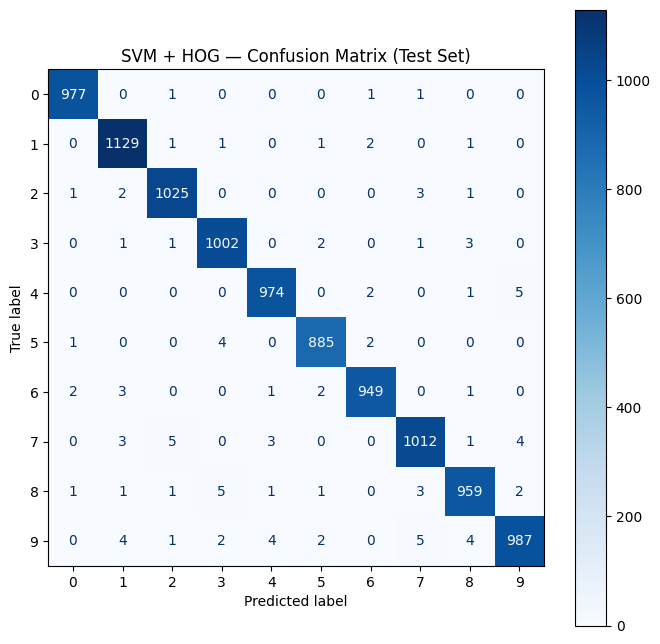

In [14]:
cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("SVM + HOG — Confusion Matrix (Test Set)")
plt.show()